1. 

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load dataset
df = pd.read_csv('voice.csv')

# 2. Encode target ('male' -> 0, 'female' -> 1)
X = df.drop('label', axis=1)
y = df['label'].map({'male': 0, 'female': 1})

# 3. Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Feature scaling (Z-score standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Build baseline KNN model
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train_scaled, y_train)

# 6. Model Evaluation
y_pred = knn_baseline.predict(X_test_scaled)
print(f"Baseline Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['male', 'female']))

Baseline Test Accuracy: 0.9748

              precision    recall  f1-score   support

        male       0.97      0.97      0.97       317
      female       0.97      0.97      0.97       317

    accuracy                           0.97       634
   macro avg       0.97      0.97      0.97       634
weighted avg       0.97      0.97      0.97       634



2. 

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Load dataset and calculate correlation with target
df = pd.read_csv('voice.csv')
X_all = df.drop('label', axis=1)
y = df['label'].map({'male': 0, 'female': 1})

# Build correlation dataframe with numeric label
correlations = X_all.copy()
correlations['label_num'] = y

# Calculate correlation specifying numeric_only=True
corr_with_target = correlations.corr(numeric_only=True)['label_num'].abs().drop('label_num').sort_values(ascending=False)

# Split dataset
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

# Feature selection experiment across top N feature subsets
feature_experiment_results = {}
for top_n in range(1, len(corr_with_target) + 1):
    selected_cols = corr_with_target.index[:top_n].tolist()
    
    scaler = StandardScaler()
    X_tr_sub = scaler.fit_transform(X_train_all[selected_cols])
    
    knn = KNeighborsClassifier(n_neighbors=5)
    cv_score = cross_val_score(knn, X_tr_sub, y_train, cv=5, scoring='accuracy').mean()
    feature_experiment_results[top_n] = (cv_score, selected_cols)

# Display cross-validation results for different feature counts
for n in range(4, 9):
    score, cols = feature_experiment_results[n]
    print(f"Top {n} Features -> 5-Fold CV Accuracy: {score:.4f}")

# Extract optimal subset
optimal_features = feature_experiment_results[6][1]
print("\nOptimal Features Employed:", optimal_features)

Top 4 Features -> 5-Fold CV Accuracy: 0.9736
Top 5 Features -> 5-Fold CV Accuracy: 0.9763
Top 6 Features -> 5-Fold CV Accuracy: 0.9818
Top 7 Features -> 5-Fold CV Accuracy: 0.9795
Top 8 Features -> 5-Fold CV Accuracy: 0.9787

Optimal Features Employed: ['meanfun', 'IQR', 'Q25', 'sp.ent', 'sd', 'sfm']


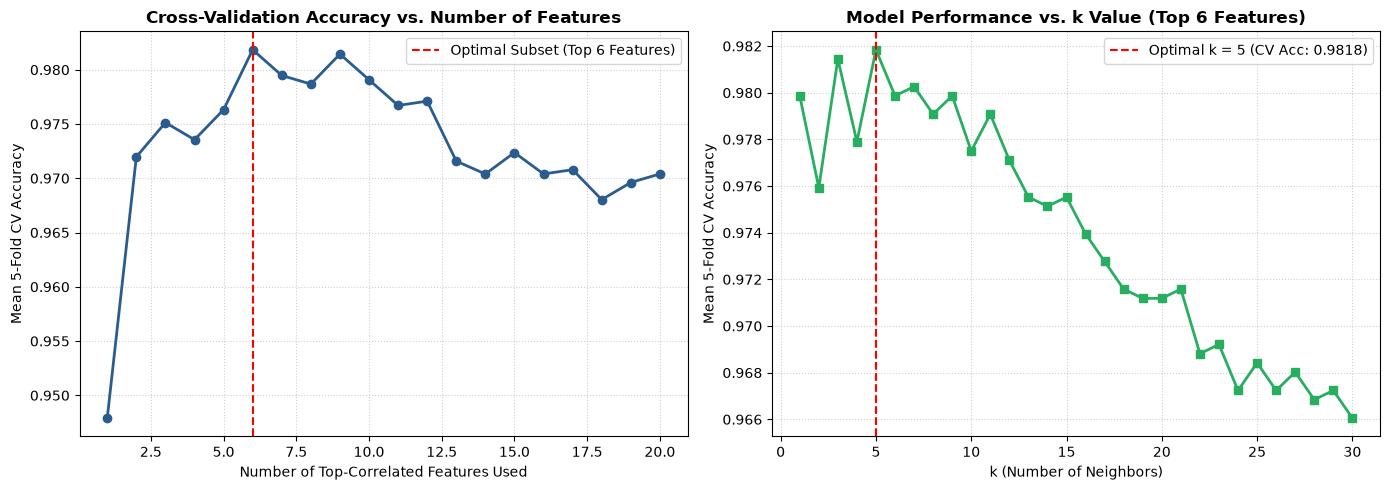

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# 1. Load Dataset & Calculate Correlations
df = pd.read_csv('voice.csv')
X_all = df.drop('label', axis=1)
y = df['label'].map({'male': 0, 'female': 1})

correlations = X_all.copy()
correlations['label_num'] = y
corr_with_target = correlations.corr(numeric_only=True)['label_num'].abs().drop('label_num').sort_values(ascending=False)

# 2. Train-Test Split
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Experiment 1: Cross-Validation vs. Number of Features (k=5)
feature_counts = list(range(1, len(corr_with_target) + 1))
cv_accs_by_features = []

for n in feature_counts:
    cols = corr_with_target.index[:n].tolist()
    scaler = StandardScaler()
    X_tr_sub = scaler.fit_transform(X_train_all[cols])
    knn = KNeighborsClassifier(n_neighbors=5)
    score = cross_val_score(knn, X_tr_sub, y_train, cv=5, scoring='accuracy').mean()
    cv_accs_by_features.append(score)

# 4. Experiment 2: Cross-Validation vs. k Value (using Top 6 Features)
optimal_6 = corr_with_target.index[:6].tolist()
scaler = StandardScaler()
X_tr_top6 = scaler.fit_transform(X_train_all[optimal_6])

k_range = list(range(1, 31))
cv_accs_by_k = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_tr_top6, y_train, cv=5, scoring='accuracy').mean()
    cv_accs_by_k.append(score)

best_k = k_range[np.argmax(cv_accs_by_k)]

# 5. Plot Both Graphs Side-by-Side (1 Row, 2 Columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: CV Accuracy vs. Number of Features
axes[0].plot(feature_counts, cv_accs_by_features, marker='o', color='#2b5c8f', linewidth=2, markersize=6)
axes[0].axvline(x=6, color='red', linestyle='--', label='Optimal Subset (Top 6 Features)')
axes[0].set_title('Cross-Validation Accuracy vs. Number of Features', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Top-Correlated Features Used', fontsize=10)
axes[0].set_ylabel('Mean 5-Fold CV Accuracy', fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# Subplot 2: CV Accuracy vs. k Value (Top 6 Features)
axes[1].plot(k_range, cv_accs_by_k, marker='s', color='#27ae60', linewidth=2, markersize=6)
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'Optimal k = {best_k} (CV Acc: {max(cv_accs_by_k):.4f})')
axes[1].set_title('Model Performance vs. k Value (Top 6 Features)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('k (Number of Neighbors)', fontsize=10)
axes[1].set_ylabel('Mean 5-Fold CV Accuracy', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()